# 项目:  电商销售数据分析报告

## 分析目标

1.了解整体销售状况与趋势  
2.识别核心产品与用户价值  
3.为运营决策提供数据支持

数据来源：某英国电商2010年12月~2011年12月交易记录

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('online_retail_cleaned_dataset.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5936\1083256152.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('online_retail_cleaned_dataset.csv')


In [3]:
df_clean = df.copy()

In [4]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,IsNotUK,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010/12/1 8:26,2.55,17850,United Kingdom,15.30,2010-12,False,NaN,NaN,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010/12/1 8:26,3.39,17850,United Kingdom,20.34,2010-12,False,NaN,Total Revenue :,NaN,8911407.904,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010/12/1 8:26,2.75,17850,United Kingdom,22.00,2010-12,False,NaN,NaN,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010/12/1 8:26,3.39,17850,United Kingdom,20.34,2010-12,False,NaN,Total Orders :,NaN,18536.000,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010/12/1 8:26,3.39,17850,United Kingdom,20.34,2010-12,False,NaN,NaN,NaN,NaN,NaN


In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  int64  
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  int64  
 7   Country      397924 non-null  object 
 8   Revenue      397924 non-null  float64
 9   Month        397924 non-null  object 
 10  IsNotUK      397924 non-null  bool   
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  4 non-null       object 
 13  Unnamed: 13  0 non-null       float64
 14  Unnamed: 14  3 non-null       float64
 15  Unnamed: 15  0 non-null       float64
dtypes: bool(1), float64(6), int64(3), object(6)
memory usage: 45.9+ MB


In [6]:
df_clean.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,IsNotUK,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True
2,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397919,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
397920,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
397921,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True
397922,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True


In [7]:
df_clean=df_clean.loc[:,~df_clean.columns.str.contains('Unnamed')]

In [8]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
397919   2011-12-09 12:50:00
397920   2011-12-09 12:50:00
397921   2011-12-09 12:50:00
397922   2011-12-09 12:50:00
397923   2011-12-09 12:50:00
Name: InvoiceDate, Length: 397924, dtype: datetime64[ns]

In [9]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(str)
df_clean['CustomerID']

0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
397919    12680
397920    12680
397921    12680
397922    12680
397923    12680
Name: CustomerID, Length: 397924, dtype: object

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  int64         
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  object        
 7   Country      397924 non-null  object        
 8   Revenue      397924 non-null  float64       
 9   Month        397924 non-null  object        
 10  IsNotUK      397924 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 30.7+ MB


In [11]:
df_clean.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Revenue
count,397924.000000,397924.000000,397924,397924.000000,397924.000000
mean,560617.126645,13.021823,2011-07-10 23:43:36.912475648,3.116174,22.394749
min,536365.000000,1.000000,2010-12-01 08:26:00,0.000000,0.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,4.680000
50%,561893.000000,6.000000,2011-07-31 14:39:00,1.950000,11.800000
75%,572090.000000,12.000000,2011-10-20 14:33:00,3.750000,19.800000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,13106.167695,180.420210,NaN,22.096788,309.055588


In [12]:
(df['Description']=='').sum()

np.int64(0)

In [13]:
(df['CustomerID']== 0).sum()

np.int64(0)

In [14]:
(df_clean['Quantity'] < 0).sum()

np.int64(0)

In [15]:
(df_clean['UnitPrice'] < 0).sum()

np.int64(0)

## **整体销售概览**    
- 原始数据共397，924条记录，包含11个字段（清洗后）
- 主要指标：  
  总销售额：8，911，407.90元  
  总订单数：18，536单  
  总客户数：4339人  
  平均客单价：480.76元  
  平均每单购买数量：279.55件

- 注：平均每单数量较高，可能存在批发订单

In [16]:
total_Revenue = df_clean['Revenue'].sum()
print(total_Revenue)

8911407.904


In [17]:
total_orders = df_clean['InvoiceNo'].nunique()
print(total_orders)

18536


In [18]:
total_Customers = df_clean['CustomerID'].nunique()
print(total_Customers)

4339


In [19]:
avg_order_price = total_Revenue / total_orders
print(avg_order_price)

480.7621873111782


In [20]:
total_quantity = df_clean["Quantity"].sum()
avg_quantity_per_order = total_quantity / total_orders
print(total_quantity)
print(avg_quantity_per_order)

5181696
279.5476909797151


In [21]:
print(f"总销售额:{total_Revenue:,.2f}元")
print(f"总订单数:{total_orders}单")
print(f"总客户数量:{total_Customers}位")
print(f"总销售数量:{total_quantity}件")
print(f"平均客单价:{avg_order_price:,.2f}元")
print(f"平均每单购买数量:{avg_quantity_per_order:,.2f}件")

总销售额:8,911,407.90元
总订单数:18536单
总客户数量:4339位
总销售数量:5181696件
平均客单价:480.76元
平均每单购买数量:279.55件


## **销售时间趋势分析**

In [22]:
monthly_sales = df_clean.groupby('Month')['Revenue'].sum().reset_index()
print(monthly_sales)

      Month      Revenue
0   2010-12   572713.890
1   2011-01   569445.040
2   2011-02   447137.350
3   2011-03   595500.760
4   2011-04   469200.361
5   2011-05   678594.560
6   2011-06   661213.690
7   2011-07   600091.011
8   2011-08   645343.900
9   2011-09   952838.382
10  2011-10  1039318.790
11  2011-11  1161817.380
12  2011-12   518192.790


In [23]:
monthly_sales['Month'] = pd.to_datetime(monthly_sales['Month'])
monthly_sales = monthly_sales.sort_values('Month')
print(monthly_sales.head(12))

        Month      Revenue
0  2010-12-01   572713.890
1  2011-01-01   569445.040
2  2011-02-01   447137.350
3  2011-03-01   595500.760
4  2011-04-01   469200.361
5  2011-05-01   678594.560
6  2011-06-01   661213.690
7  2011-07-01   600091.011
8  2011-08-01   645343.900
9  2011-09-01   952838.382
10 2011-10-01  1039318.790
11 2011-11-01  1161817.380


In [24]:
print(monthly_sales.to_string(index = False))

     Month     Revenue
2010-12-01  572713.890
2011-01-01  569445.040
2011-02-01  447137.350
2011-03-01  595500.760
2011-04-01  469200.361
2011-05-01  678594.560
2011-06-01  661213.690
2011-07-01  600091.011
2011-08-01  645343.900
2011-09-01  952838.382
2011-10-01 1039318.790
2011-11-01 1161817.380
2011-12-01  518192.790


## **月度销售折线图**

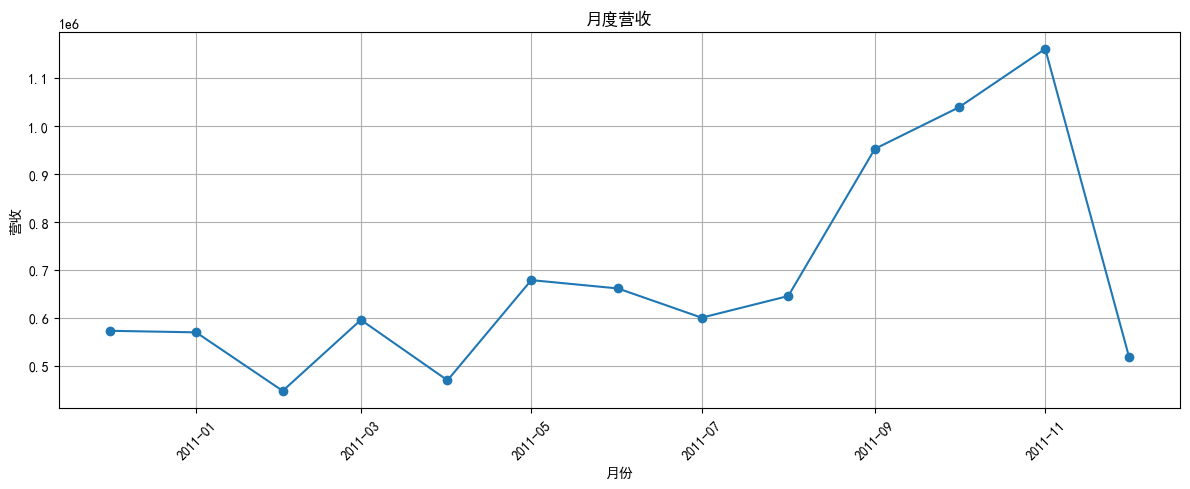

In [25]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize = (12 , 5))
plt.plot(monthly_sales['Month'],monthly_sales['Revenue'],marker = 'o', linestyle = '-')
plt.title('月度营收')
plt.xlabel('月份')
plt.ylabel('营收')
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
monthly_sales['Month'] = pd.to_datetime(monthly_sales['Month'])
monthly_sales.dtypes

Month      datetime64[ns]
Revenue           float64
dtype: object

In [27]:
max_month = monthly_sales.loc[monthly_sales['Revenue'].idxmax()]
min_month = monthly_sales.loc[monthly_sales['Revenue'].idxmin()]
print('\n分析结论')
print(f"销售额最高月份:{max_month['Month'].strftime('%Y-%m')},销售额:{max_month['Revenue']:,.2f}元")
print(f"销售额最低月份:{min_month['Month'].strftime('%Y-%m')},销售额:{min_month['Revenue']:,.2f}元")


分析结论
销售额最高月份:2011-11,销售额:1,161,817.38元
销售额最低月份:2011-02,销售额:447,137.35元


- **销售额最高月份**:2011-11,销售额:1,161,817.38元
- **销售额最低月份**:2011-02,销售额:447,137.35元
- **趋势解读**：下半年销售明显增长，11月达到峰值，可能与“黑色星期五”或圣诞促销有关；2月为淡季

## **用户分层 （RFM分析)**

R(Recency):客户最近一次购买日期(越近越好)    
F(Frequency):客户购买次数(越多越好)    
M(Monetary):客户总消费金额(越高越好)   

R(Recency)计算

In [28]:
ref_date = df_clean['InvoiceDate'].max() + pd.DateOffset(days = 1)
print(f'参考日期：{ref_date}')

参考日期：2011-12-10 12:50:00


In [29]:
recency_raw = df_clean.groupby('CustomerID')['InvoiceDate'].max()

In [30]:
recency = (ref_date - recency_raw).dt.days
print(recency.head())

CustomerID
12346    326
12347      2
12348     75
12349     19
12350    310
Name: InvoiceDate, dtype: int64


F(Frequency)计算

In [31]:
frequency = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
print(frequency.head())

CustomerID
12346    1
12347    7
12348    4
12349    1
12350    1
Name: InvoiceNo, dtype: int64


M(Monetary)计算

In [32]:
monetary = df_clean.groupby('CustomerID')['Revenue'].sum()
print(monetary.head())

CustomerID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
Name: Revenue, dtype: float64


合并RFM

In [33]:
rfm = pd.DataFrame({'Recency':recency , 'Frequency':frequency , 'Monetary':monetary})
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


RFM评分

R：天数越小越好，反向打分，最小的天数给最高分 4 分   
F：次数越多越好，正向打分，最大的次数给最高分 4 分  
M：金额越高越好，正向打分，最大的金额给最高分 4 分  
按四分位数等频分箱（每组大约25%的客户）

In [34]:
r_quantiles = rfm['Recency'].quantile([0.25 , 0.5 , 0.75])
f_quantiles = rfm['Frequency'].quantile([0.25 , 0.5 , 0.75])
m_quantiles = rfm['Monetary'].quantile([0.25 , 0.5 , 0.75])
def score_r(x):
    if x <= r_quantiles[0.25]:
        return 4
    elif x <= r_quantiles[0.5]:
        return 3
    elif x <= r_quantiles[0.75]:
        return 2
    else:
        return 1

def score_f(x):
    if x >= f_quantiles[0.75]:
        return 4
    elif x >= f_quantiles[0.5]:
        return 3
    elif x >= f_quantiles[0.25]:
        return 2
    else:
        return 1

def score_m(x):
    if x >= m_quantiles[0.75]:
        return 4
    elif x >= m_quantiles[0.5]:
        return 3
    elif x >= m_quantiles[0.25]:
        return 2
    else:
        return 1

In [35]:
rfm['R_score'] = rfm['Recency'].apply(score_r)
rfm['F_score'] = rfm['Frequency'].apply(score_f)
rfm['M_score'] = rfm['Monetary'].apply(score_m)
print(rfm[['Recency', 'R_score' , 'Frequency' , 'F_score' , 'Monetary' , 'M_score']].head())

            Recency  R_score  Frequency  F_score  Monetary  M_score
CustomerID                                                         
12346           326        1          1        2  77183.60        4
12347             2        4          7        4   4310.00        4
12348            75        2          4        3   1797.24        4
12349            19        3          1        2   1757.55        4
12350           310        1          1        2    334.40        2


把三个分数合并为总分或者等级

In [36]:
#总分(范围3~12)
rfm['Total_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

In [37]:
def customer_segment(score):
    if score >= 10:
        return '高价值'
    elif score >= 7:
        return '中价值'
    else:
        return '低价值'

In [38]:
order = ['高价值' , '中价值' , '低价值']
rfm['Segment'] = rfm['Total_Score'].apply(customer_segment)
print(rfm['Segment'].value_counts().reindex(order))

Segment
高价值    1331
中价值    1557
低价值    1451
Name: count, dtype: int64


In [39]:
high_value_customers = rfm[rfm['Segment'] == '高价值']
print(high_value_customers.head(10))

            Recency  Frequency  Monetary  R_score  F_score  M_score  \
CustomerID                                                            
12347             2          7   4310.00        4        4        4   
12352            36          8   2506.04        3        4        4   
12356            23          3   2811.43        3        3        4   
12358             2          2   1168.06        4        3        3   
12362             3         10   5226.23        4        4        4   
12364             8          4   1313.10        4        3        3   
12370            51          4   3545.69        3        3        4   
12371            45          2   1887.96        3        3        4   
12380            22          4   2724.81        3        3        4   
12381             5          5   1845.31        4        4        4   

            Total_Score Segment  
CustomerID                       
12347                12     高价值  
12352                11     高价值  
12356      

## **产品分析（帕累托法则）**  
- 共有3665种不同产品
- **前20%的产品（733种）贡献了78.65%的销售额**，符合“二八定律”
- 销售额前10的产品代码及对应销售额（水平条形图）：

In [40]:
product_sales = df_clean.groupby('StockCode')['Revenue'].sum().sort_values(ascending = False)
top10_products = product_sales.head(10)
print(top10_products)

StockCode
23843     168469.60
22423     142592.95
85123A    100603.50
85099B     85220.78
23166      81416.73
POST       77803.96
47566      68844.33
84879      56580.34
M          53779.93
23084      51346.20
Name: Revenue, dtype: float64


In [41]:
total_products = df_clean['StockCode'].nunique()
print(total_products)

3665


In [42]:
top_n = max(1,int(total_products * 0.2))
top_products = product_sales.head(top_n)
top_sales_sum = top_products.sum()
total_sales = product_sales.sum()
share = top_sales_sum / total_sales
print(f'前百分之20%的产品(共{top_n}种)贡献的销售额占比:{share:.2%}')

前百分之20%的产品(共733种)贡献的销售额占比:78.65%


**建议: 重点维护前20%的头部产品，并分析其关联购买机会**

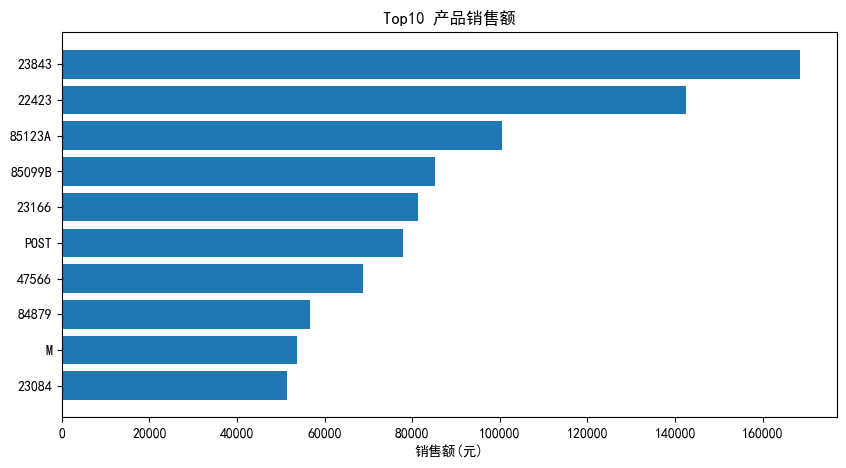

In [43]:
top_10 = product_sales.head(10)
plt.figure(figsize = (10 , 5))
plt.barh(top_10.index.astype(str) , top_10.values)
plt.xlabel('销售额(元)')
plt.title('Top10 产品销售额')
plt.gca().invert_yaxis()
plt.show()

## **客户价值分布**

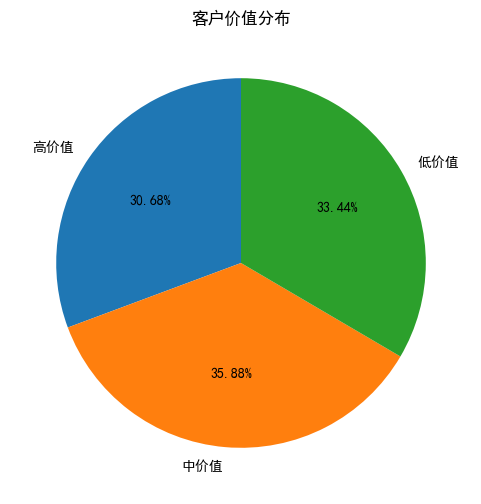

In [44]:
segment_counts = rfm['Segment'].value_counts().reindex(['高价值' , '中价值' , '低价值'])
plt.figure(figsize = (6 ,6))
plt.pie(segment_counts , labels = segment_counts.index , autopct = '%1.2f%%' , startangle = 90)
plt.title('客户价值分布')
plt.show()

- **高价值客户**： 1331人 占比：30.68%  
- **中价值客户**： 1557人 占比：35.88%
- **低价值客户**： 1451人 占比：33.44%

**分布较均匀**，高价值客户数量略少，但其人均贡献远高于其他群体

## **业务建议**

**客户层面**  
- 高价值：提供专属权益（VIP折扣，优先发货，生日礼包，双倍积分），提升复购与忠诚度，可尝试交叉销售高利润产品  
- 中价值：刺激频次或客单价，如发放满减券，第二件半价，任务体系（累计消费送礼品），引导向高价值转换    
- 低价值：用低成本唤醒，如发放优惠券或新品提醒；若多次无响应则减少营销投入，沉默处理，避免资源浪费


**产品层面**  
保证头部20%产品库存充足，在11月旺季来临之前提前备货，针对2月淡季可策划主题促销（如情人节，清仓等）  


**时间层面**  
借鉴11月的成功经验，在每年10-11月加大广告投放和活动力度

## **总结**  
- 该电商业务呈现**明显季节波动**，头部产品贡献度突出，客户价值分布健康。
- 建议**实施RFM分层运营**，集中资源维护高价值客户，同时通过优惠活动提升中价值客户的活跃度，实现整体业绩增长

报告完成日期：2025年7月  
分析工具：Python(Pandas,matplolib)